In [5]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from matplotlib.lines import Line2D
from matplotlib_venn import venn3  # pip install matplotlib-venn if needed
import importlib
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at
import matplotlib as mpl
from src.significant_traces import compute_noise_model_romano_fast_modular, plot_dff_and_raster

plt.style.use('default')
# %matplotlib qt
%matplotlib inline
# comments about fish quality:
#L433_f02: good fish, but the response is mostly one side

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import sys
print(sys.version)
print(sys.executable)

3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
c:\ProgramData\miniconda3\envs\social_filters\python.exe


In [31]:
# ==== CONFIG ================================================================
importlib.reload(exio)

fish_id = "L684_f07"
experiment_name = "Exp_5_map_positions"#"Exp_2_rocking_1" #"Exp_3_rocking_2"
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
stimuli_main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\stimuli")

# stimuli_main_path = Path(r"\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Alejandro\2p")
fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]
t_pre_s  = 5.0   # time before onset to include
t_post_s = 32.0  # time after onset to include
# ==== LOAD EVERYTHING IN ONE GO ============================================
results = exio.load_2p_experiment(
    fish_id=fish_id,
    experiment_name=experiment_name,
    main_path=main_path,
    stimuli_main_path=stimuli_main_path,
    fps_2p=fps_2p,
    selected_blocks=selected_blocks,
)

dfof              = results["dfof"]
stimuli_durations = results["stimuli_durations"]
exp_log           = results["adjusted_log"]
stimuli_trace_60  = results["stimuli_trace_60"]
stimuli_table     = results["stimuli_table"]
stimuli_id_map    = results["stimuli_id_map"]
duration_2p_block_sec = results["duration_2p_block_sec"]
frames_per_block       = results["frames_per_block"]
paths                  = results["paths"]
raster                 = results["raster"]
dfof_center =           results["deltaF_center"]
dFoF_merged_map =       results["dFoF_merged_map"]
plane_ids =             results["plane_ids"]
mean_imgs =             results["mean_imgs"]
stat_per_plane =        results["stat_per_plane"]


✅ Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f07_Exp_5_map_positions\03_analysis\functional\plots\significant_traces\L684_f07_significant_traces.npz
✅ Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f07_Exp_5_map_positions\03_analysis\functional\plots\filtered_neurons_by_stimuli\L684_f07_kept_neuron_indices.npy
✅ Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f07_Exp_5_map_positions\03_analysis\functional\suite2P\merged_dFoF\L684_f07_dFoF_merged_filtered_roi_indices.npy
✅ Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f07_Exp_5_map_positions\03_analysis\functional\plots\z_core\L684_f07_zcore.npz
dFoF_merged_map: (539, 6)
Loaded planes: ['plane0', 'plane1', 'plane2', 'plane3', 'plane4']
✅ Using preferred dFoF file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684

In [32]:
# detect Z-score, as a base line a contatenated trace of traces pre-stimulu

# detect onset of stimuli
res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )
onsets_by_id= res["onsets_by_id"]

zres = at.zscore_dfof_from_prestim_baseline(
    dfof=dfof,
    onsets_by_id=onsets_by_id,
    fps_2p=fps_2p,
    baseline_s=10.0,
    assume_time_by_neuron=True,
    verbose=True,
)

z_traces = zres["z_traces"]

prefix = paths["prefix"]
folder_zcore = paths["plots_path"] / 'z_core'
folder_zcore.mkdir(parents=True, exist_ok=True)
out_zcore = folder_zcore / f"{prefix}_zcore.npz"

np.savez(
    out_zcore,
    z_traces=zres["z_traces"],
    baseline_mean=zres["baseline_mean"],
    baseline_std=zres["baseline_std"],
    valid_onsets=zres["valid_onsets"]
)

print(f"Saved z_traces to {out_zcore}")


Number of neurons: 539
Number of time points: 4064
2p duration (s): 2032.0
60Hz duration from data (s): 2026.7
Output stim trace shape: (4064,)
Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Stimuli names: ['FlickL', 'FlickR', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'LeBcontrol', 'RiB1', 'RiB2', 'RiB3', 'RiB4', 'RiBcontrol', 'RockL', 'RockR']
stim 1: 4 onsets | kept 4 trials | dropped 0
stim 2: 4 onsets | kept 4 trials | dropped 0
stim 3: 4 onsets | kept 4 trials | dropped 0
stim 4: 4 onsets | kept 3 trials | dropped 1
stim 5: 4 onsets | kept 4 trials | dropped 0
stim 6: 4 onsets | kept 4 trials | dropped 0
stim 7: 4 onsets | kept 4 trials | dropped 0
stim 8: 4 onsets | kept 4 trials | dropped 0
stim 9: 4 onsets | kept 4 trials | dropped 0
stim 10: 4 onsets | kept 4 trials | dropped 0
stim 11: 4 onsets | kept 4 trials | dropped 0
stim 12: 4 onsets | kept 4 trials | dropped 0
stim 13: 4 onsets | kept 4 trials | dropped 0
stim 14: 4 onsets | kept 4 trials | dropped 0
n_neurons: 539

In [33]:
# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'FlickL': sns.color_palette('dark:#404040', 10)[7],
    'FlickR': sns.color_palette('dark:#404040', 10)[7],
    'LeB1': sns.color_palette('Blues', 8)[7],
    'LeB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'LeB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'RiB1': sns.color_palette('Blues', 8)[7],
    'RiB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'RiB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'LeB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'RiB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'LeBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RiBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RockL': sns.color_palette('PuRd', as_cmap=True)(0.6),
    'RockR': sns.color_palette('PuRd', as_cmap=True)(0.6),
}
linestyles_C = {
    'FlickR': '--',
    'RiB1': '--',
    'RiB2': '--',
    'RiB3': '--',
    'RiB4': '--',
    'RiBcontrol': '--',
    'RockR': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = [
    'LeBcontrol',
    'RiBcontrol',
    'LeB1',
    'LeB2',
    'LeB3',
    'LeB4',
    'RiB1',
    'RiB2',
    'RiB3',
    'RiB4',
    'RockL',
    'RockR',
    'FlickL',
    'FlickR'
]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_5_map_positions
{'FlickR': '--', 'RiB1': '--', 'RiB2': '--', 'RiB3': '--', 'RiB4': '--', 'RiBcontrol': '--', 'RockR': '--'}


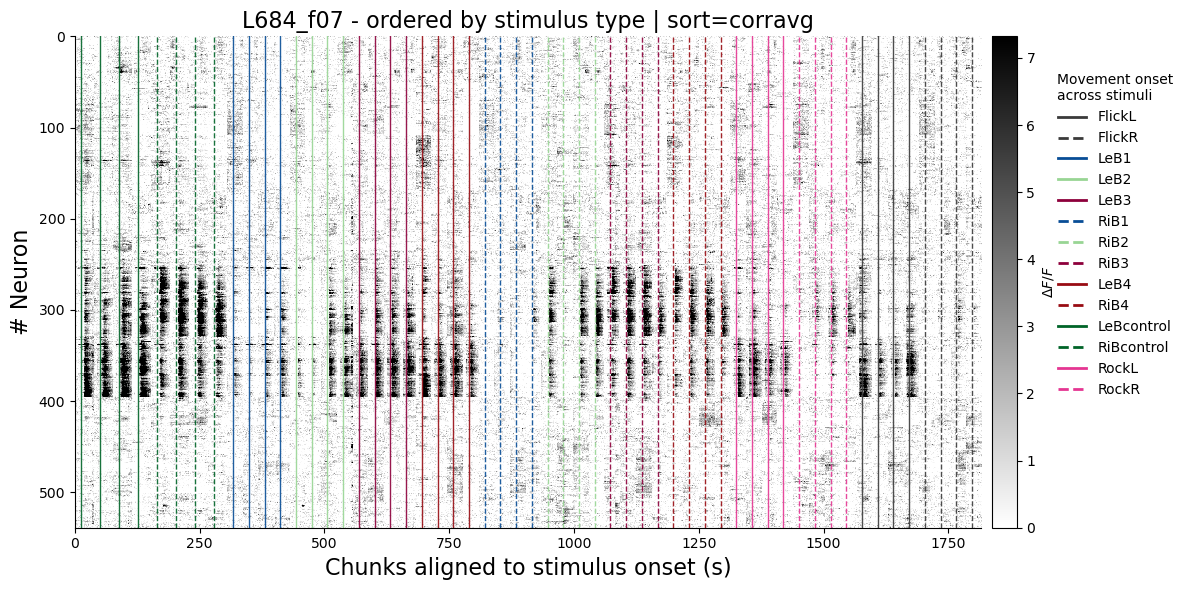

In [34]:
# --- Plot sorted chunks for a single mode ---
# Sort by kmeans, pca, hier, covariance, max_intensity, none(unsorted), just modified sort mode
# for average_across_repeats = True or False

fig, ax, order = plott.plot_sorted_chunks_single_mode(
    dfof=z_traces,
    exp_log=exp_log,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    stimuli_ordered=stimuli_ordered,
    fps_2p=fps_2p,
    window_pre=window_pre,
    window_post=window_post,
    sort_mode="corravg",        # or 'pca', 'hier', 'corravg', max_intensity, kmeans, none(unsorted) ...
    n_clusters=5,
    random_state=42,
    average_across_repeats=False, # 👈 False to keep all repeats True to average across repeats
    fish_id=fish_id,
    neuron_order=None,       # 👈 custom order (optional)
    sort_label=None,
    vmax=None,# 👈 label to show in the title
)
plt.show()

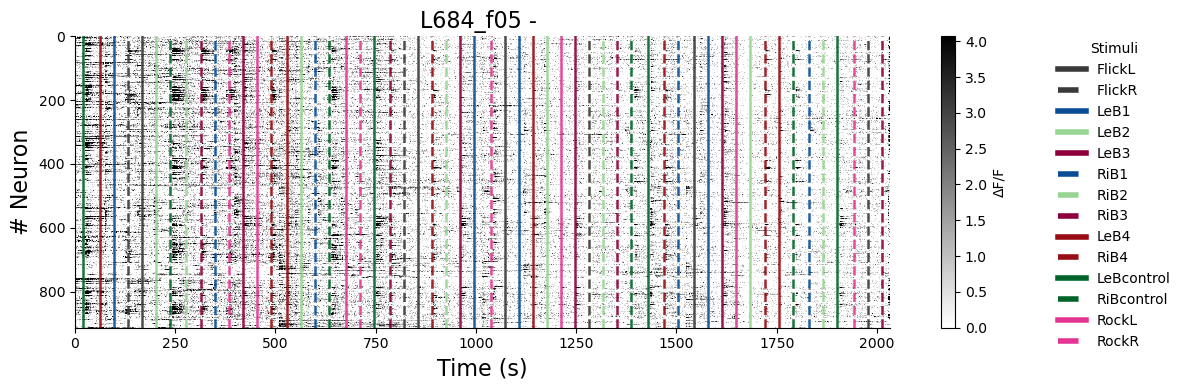

In [26]:
# simple plot of delfta F over F with stimuli markers

fig, ax = plt.subplots(figsize=(12, 4))

# call your function — use vmax (or vmin/vmax) depending on your signature
im = plott.raster_with_stimuli(
    ax=ax,
    data=z_traces ,
    fps=fps_2p,
    fish_id=fish_id,
    vmax=None,        # if your function still uses min/max, use min=0, max=0.4 instead
)

# add stimuli markers & legend on the SAME axes
legend_handles = plott.add_stimuli_markers(ax, exp_log, stimuli_durations, stimuli_colors,stimuli_linestyles=stimuli_linestyles)
ax.legend(handles=legend_handles, title="Stimuli",
          bbox_to_anchor=(1.2, 1), loc='upper left', borderaxespad=0, frameon=False)

ax.set_xlabel("Time (s)")

# add colorbar to the SAME figure
fig.colorbar(im, ax=ax, label="ΔF/F")

fig.tight_layout()
plt.show()

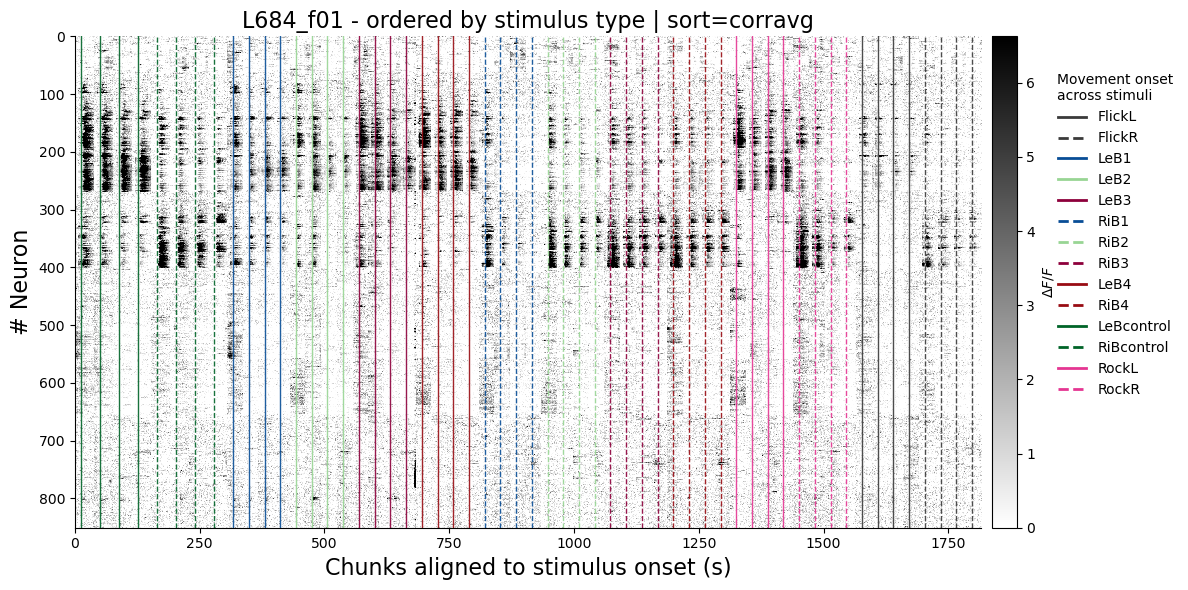

In [108]:
## Generate trial-aligned traces regarding stimuli
# Build trial-aligned traces, i.e., snippets of dF/F around each stimulus onset
# you define the pre- and post- time windows (in seconds) onset_begining of stimuli___moving.
t_pre_s = 5.0  # time before onset to include
t_post_s = 29.0  # time after onset to include

res = at.build_trial_aligned_traces(
    dfof=dfof,
    stimuli_trace_60=stimuli_trace_60,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    t_post_s=t_post_s,
    stimuli_id_map=stimuli_id_map,  # or None
    verbose=True
)

trial_aligned_traces = res["trial_aligned_traces"]  # dict: stim_id -> (n_neurons, n_trials_frames_per_trial) Df/F
stimuli_ids = res["stimuli_ids"]  # list of stim_ids used
stimuli_names = res["stimuli_names"]  # list of stim_names used
win_length = res["win_length"]  # n_frames_per_trial
stimuli_trace = res["stimuli_trace"]  # (n_frames_total,) stimulus trace used for alignment
onsets_by_id = res["onsets_by_id"]  # dict: stim_id -> (n_trials,) onset frames (global indices)


Number of neurons: 851
Number of time points: 4064
2p duration (s): 2032.0
60Hz duration from data (s): 2026.7
Output stim trace shape: (4064,)
Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Stimuli names: ['FlickL', 'FlickR', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'LeBcontrol', 'RiB1', 'RiB2', 'RiB3', 'RiB4', 'RiBcontrol', 'RockL', 'RockR']
stim 1: 4 onsets | kept 4 trials | dropped 0
stim 2: 4 onsets | kept 4 trials | dropped 0
stim 3: 4 onsets | kept 4 trials | dropped 0
stim 4: 4 onsets | kept 4 trials | dropped 0
stim 5: 4 onsets | kept 3 trials | dropped 1
stim 6: 4 onsets | kept 4 trials | dropped 0
stim 7: 4 onsets | kept 4 trials | dropped 0
stim 8: 4 onsets | kept 4 trials | dropped 0
stim 9: 4 onsets | kept 4 trials | dropped 0
stim 10: 4 onsets | kept 4 trials | dropped 0
stim 11: 4 onsets | kept 4 trials | dropped 0
stim 12: 4 onsets | kept 4 trials | dropped 0
stim 13: 4 onsets | kept 4 trials | dropped 0
stim 14: 4 onsets | kept 4 trials | dropped 0


In [109]:
# average the  activity of neurons in repetition per stimuli
# Containers (per stimulus → arrays of shape (n_kept,))
mean_traces = {}   # trial-averaged timecourses (kept neurons)
pre_frames  = int(round(t_pre_s * fps_2p))
post_frames = int(round(t_post_s * fps_2p))
win_lenght = pre_frames + post_frames
dt = 1.0 / float(fps_2p) #time per frame (the sampling interval) in seconds
# Containers (per stimulus → arrays of shape (n_kept,))
mean_traces = {}   # trial-averaged timecourses (kept neurons)
peaks = {}
aucs  = {}
averages = {}

for stim in stimuli_ids:
    X = trial_aligned_traces[stim]                      # (n_neurons, win_lenght, n_trials)
    Xkept = X[:, :, :]                   # filter kept neurons
    mean_trace = np.nanmean(Xkept, axis=2)                # (kept_neurons, win_lenght)
    mean_traces[stim] = mean_trace

    # Stimulus window (without pre stim frames)
    Y = mean_trace[:, pre_frames:win_lenght]                # (n_kept, n_post)
    peaks[stim] = np.nanmax(Y, axis=1) # peak ΔF/F
    aucs[stim]  = np.trapezoid(np.nan_to_num(Y), dx=dt, axis=1)  # AUC (ΔF/F * s), NaNs→0
    averages[stim] = np.nanmean(Y, axis=1)

[warn] No linestyle for: ['FlickL', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'LeBcontrol', 'RockL'] → using solid '-'.


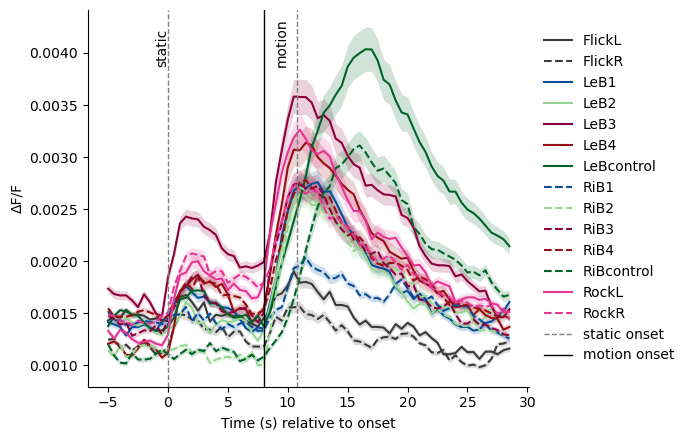

In [110]:
fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=mean_traces,
    stimuli_ids=stimuli_ids,
    stimuli_names=stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=paths["plots_path"],       # Path object or str
    prefix=paths['prefix'],               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)


Saved kept neuron indices to: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\filtered_neurons_by_stimuli\L684_f01_kept_neuron_indices.npy


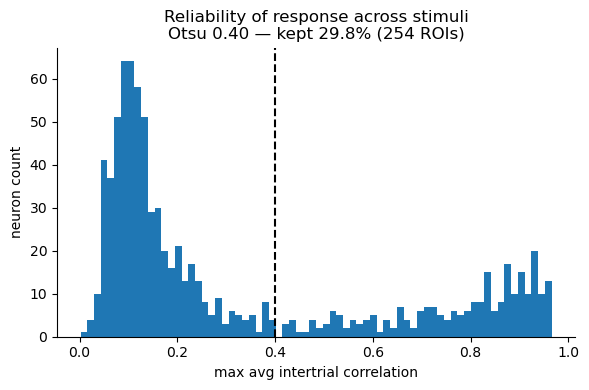

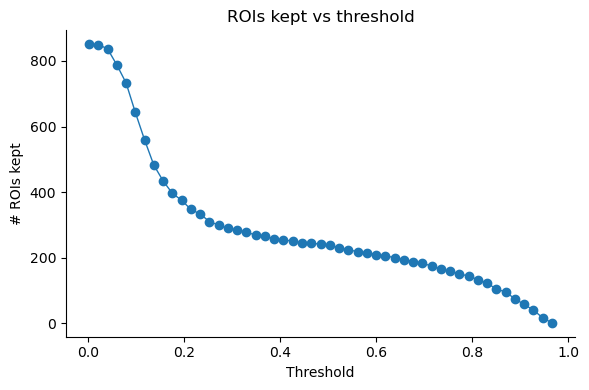

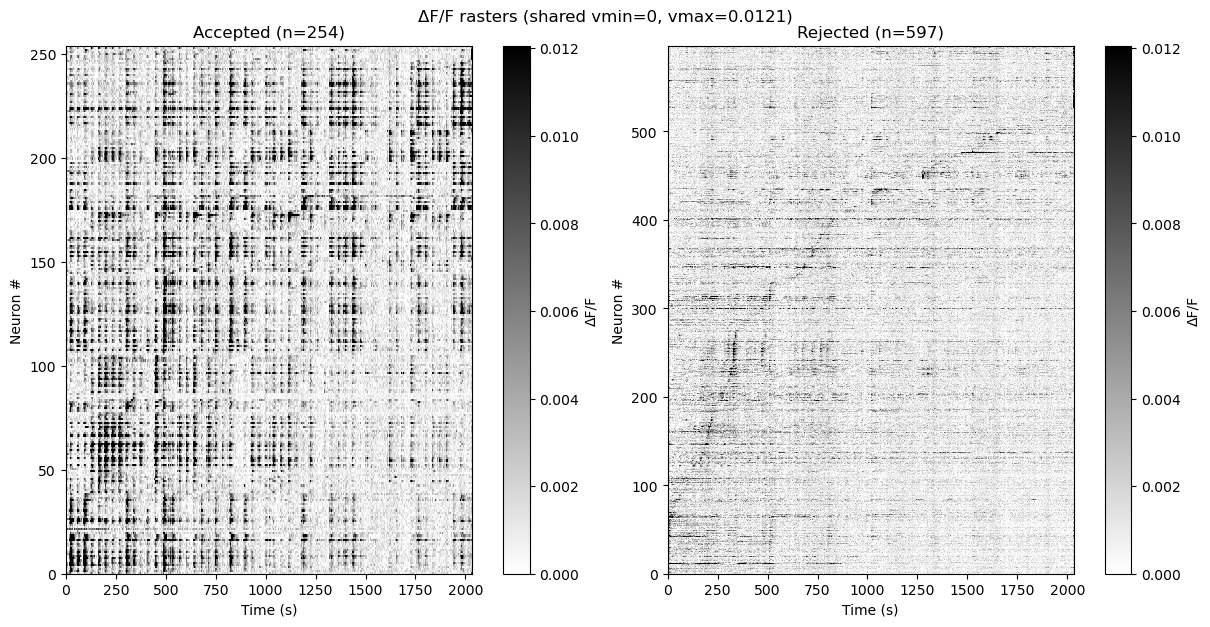

Kept 254 neurons after reliability filtering.


In [111]:
# Filter neurons by trial reliability
# This function computes the trial reliability for each neuron and filters out
# those that do not meet a certain reliability threshold.
# It also generates plots to visualize the reliability distribution and
# the traces of kept vs. discarded neurons.
results = at.filter_neurons_by_trial_reliability(
    dfof=dfof,                        # shape (T, n_neurons)
    trial_aligned_traces=trial_aligned_traces,
    stimuli_ids=stimuli_ids,
    fps_2p=fps_2p,
    plots_path=paths["plots_path"],
    prefix=paths["prefix"],
    costom_threshold = 0.4,
    folder_name="filtered_neurons_by_stimuli",
    make_plots=True,      # switch to False if you don't want any plots
    save_indices=True,    # switch to False if you don't want to save the .npy
)

kept_neuron_indices = results["kept_neuron_indices"]
print(f"Kept {len(kept_neuron_indices)} neurons after reliability filtering.")

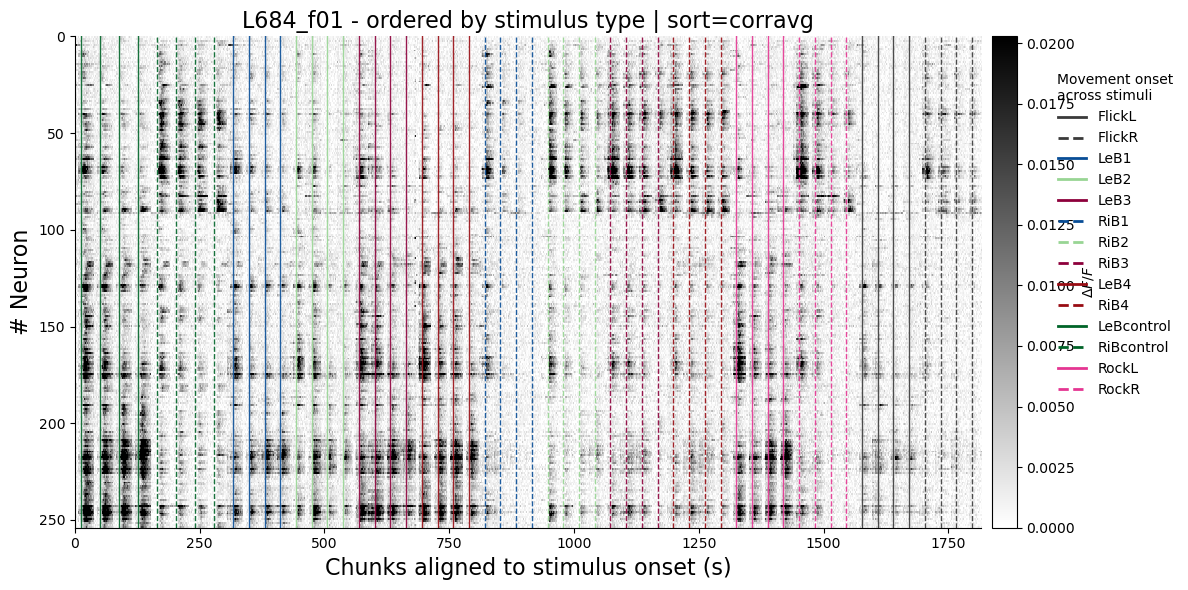

In [112]:
# --- Plot sorted chunks for a single mode ---
# Sort by kmeans, pca, hier, covariance, max_intensity, none(unsorted), just modified sort mode
# for average_across_repeats = True or False
dfof_kept=dfof[:, kept_neuron_indices]
fig, ax, order = plott.plot_sorted_chunks_single_mode(
    dfof=dfof_kept,
    exp_log=exp_log,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    stimuli_ordered=stimuli_ordered,
    fps_2p=fps_2p,
    window_pre=window_pre,
    window_post=window_post,
    sort_mode="corravg",        # or 'pca', 'hier', 'corravg', max_intensity, kmeans, none(unsorted) ...
    n_clusters=5,
    random_state=42,
    average_across_repeats= False, # 👈 False to keep all repeats True to average across repeats
    fish_id=fish_id,
    neuron_order=None,       # 👈 custom order (optional)
    sort_label=None,         # 👈 label to show in the title
)
plt.show()

[warn] No linestyle for: ['FlickL', 'LeB1', 'LeB2', 'LeB3', 'LeB4', 'LeBcontrol', 'RockL'] → using solid '-'.


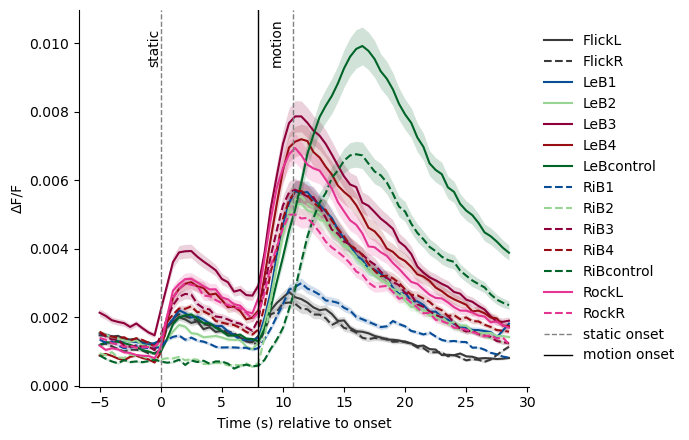

In [113]:
kept_neuron_indices = results["kept_neuron_indices"]
# average the  activity of neurons in repetition per stimuli
# Containers (per stimulus → arrays of shape (n_kept,))
mean_traces = {}   # trial-averaged timecourses (kept neurons)

for stim in stimuli_ids:
    X = trial_aligned_traces[stim]                      # (n_neurons, win_lenght, n_trials)
    Xkept = X[kept_neuron_indices, :, :]                   # filter kept neurons
    mean_trace = np.nanmean(Xkept, axis=2)                # (kept_neurons, win_lenght)
    mean_traces[stim] = mean_trace

fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=mean_traces,
    stimuli_ids=stimuli_ids,
    stimuli_names=stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=paths["plots_path"],       # Path object or str
    prefix=paths['prefix'],               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)



In [90]:
# Plot significant traces only - filtered neurons only
# Compute significant traces using the modified Romano et al. method

dfof_kept=dfof[:, kept_neuron_indices] # neurons responsive to stimuli only
FPS_DEFAULT = 2.0
TAUDECAY_DEFAULT = 6.0

ST_N_BINS       = 1300
ST_K_NEIGHBORS  = 100
ST_CONF_CUTOFF  = 90
ST_PLOT_ODDS    = False
ST_VMAX_DFF     = 0.15

(mapOfOdds,
         deltaF_center,
         density_data,
         density_noise,
         xev, yev,
         raster,
         mapOfOddsJoint) = compute_noise_model_romano_fast_modular(
             dfof_kept,
             n_bins=ST_N_BINS,
             k_neighbors=ST_K_NEIGHBORS,
             confCutOff=ST_CONF_CUTOFF,
             plot_odds=ST_PLOT_ODDS,
             fps=FPS_DEFAULT,
             tauDecay=TAUDECAY_DEFAULT,
        )

prefix=paths["prefix"]
folder_raster = paths["plots_path"] / 'significant_traces'
folder_raster.mkdir(parents=True, exist_ok=True)

out_raster = folder_raster / f"{prefix}_significant_traces.npz"
np.savez(
    out_raster,
    raster=raster,
    deltaF_center=deltaF_center,
)

print(f"Saved significant traces to {out_raster}")

[Noise Fit] Used fallback on 0 out of 163 ROIs (0.0%)
Saved significant traces to D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f07_Exp_5_map_positions\03_analysis\functional\plots\significant_traces\L684_f07_significant_traces.npz


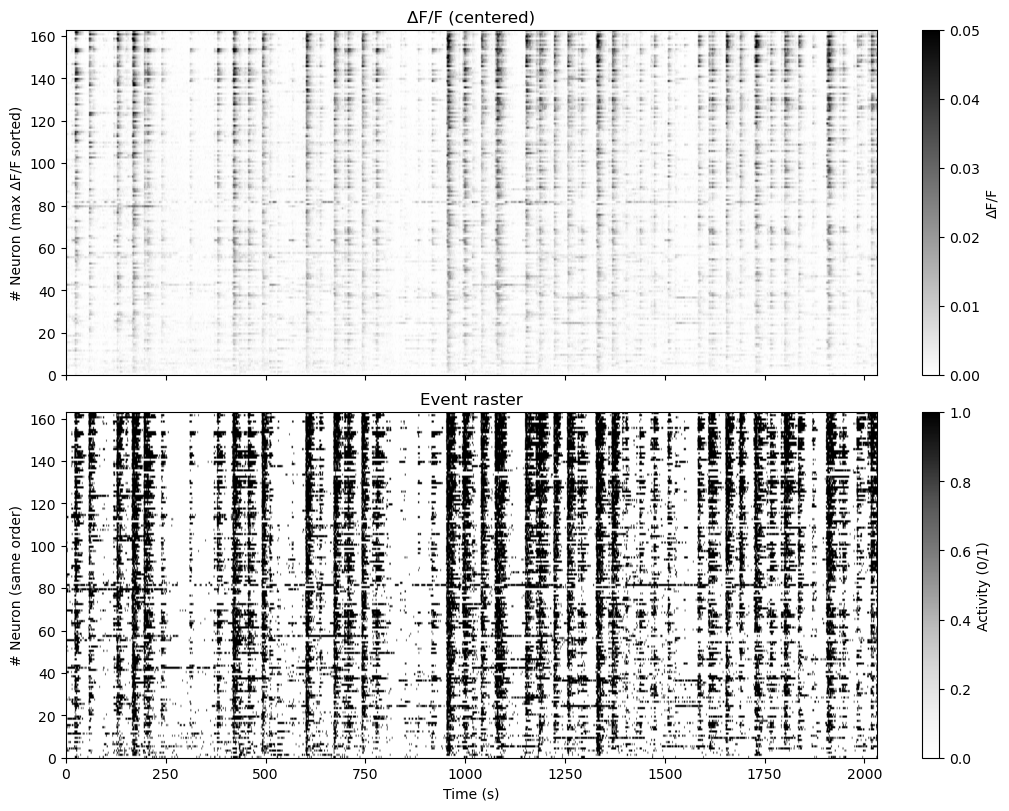

In [91]:
sort_idx = plot_dff_and_raster(deltaF_center, raster, fps=2.0, vmax_dff=0.05)

In [117]:
## plot example dF/F and raster to check if significant traces look ok.

# sort_idx = plot_dff_and_raster(deltaF_center[:,1:100], raster[:,1:100], fps=2.0, vmax_dff=0.3)

# Sanity check before pdist
n_neurons =raster.shape[1] #  frames x nueroso
nan_mask = ~np.isfinite(raster).all(axis=0)
zero_var_mask = np.nanstd(raster, axis=0) == 0
bad_mask = nan_mask | zero_var_mask              # neurons to remove
good_mask = ~bad_mask
raster_clean = raster[:,good_mask]

print("Neurons with any NaN:", np.where(nan_mask)[0])
print("Neurons with zero variance:", np.where(zero_var_mask)[0])
print("Total bad neurons:", np.sum(nan_mask | zero_var_mask), "out of", n_neurons)

Neurons with any NaN: []
Neurons with zero variance: []
Total bad neurons: 0 out of 325


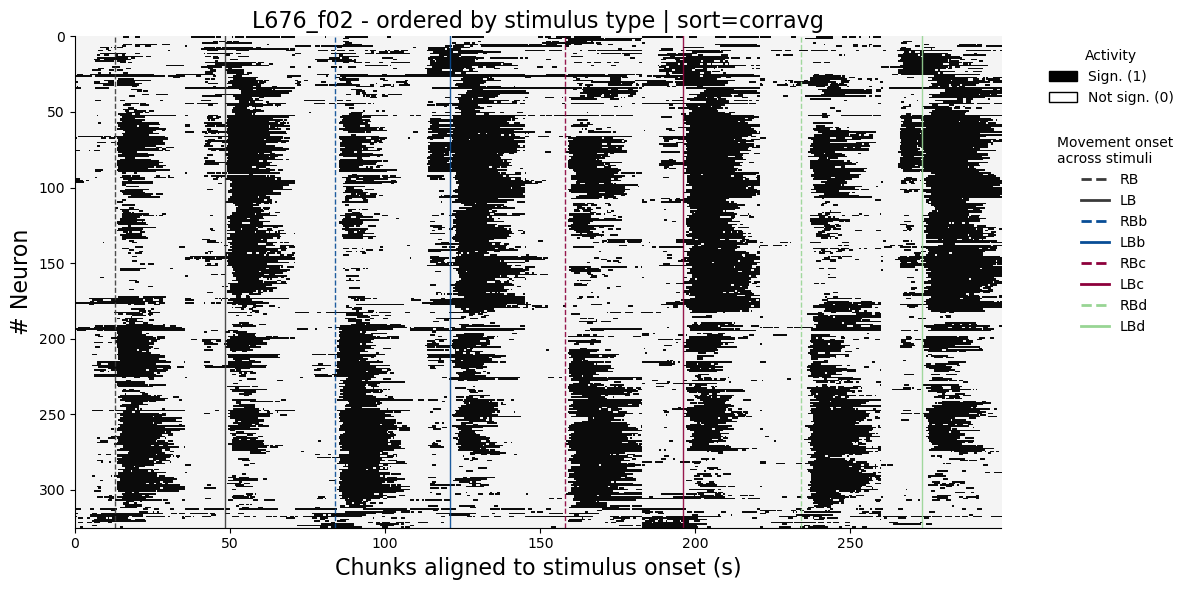

In [118]:

# here for plotting significant traces only
# --- Plot sorted chunks for a single mode ---
# Sort by kmeans, pca, hier, covariance, max_intensity, none(unsorted), just modified sort mode
# for average_across_repeats = True or False

# id there is not variability of NaN correlation does not work
importlib.reload(plott)
fig, ax, order = plott.plot_sorted_chunks_single_mode(
    dfof=raster_clean,
    exp_log=exp_log,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    stimuli_ordered=stimuli_ordered,
    fps_2p=fps_2p,
    window_pre=window_pre,
    window_post=window_post,
    sort_mode="corravg",        # or 'pca', 'hier', 'corravg', max_intensity, kmeans, none(unsorted) ...
    n_clusters=4,
    random_state=42,
    average_across_repeats=True,#👈 False to keep all repeats True to average across repeats
    fish_id=fish_id,
    neuron_order=None,       # 👈 custom order (optional)
    sort_label=None,# 👈 label to show in the title
    is_binary = True,
)
plt.show()

